#analisis awal

In [24]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.dpi'] = 100

In [25]:
data_basepath = "dataset"
data_klaimpath = f"{data_basepath}/Data_Klaim.csv"
data_polispath = f"{data_basepath}/Data_Polis.csv"

data_klaim = pd.read_csv(data_klaimpath, parse_dates=['Tanggal Pembayaran Klaim', 'Tanggal Pasien Masuk RS', 'Tanggal Pasien Keluar RS'])
data_klaim.head()

,Claim ID,Nomor Polis,Reimburse/Cashless,Inpatient/Outpatient,ICD Diagnosis,ICD Description,Status Klaim,Tanggal Pembayaran Klaim,Tanggal Pasien Masuk RS,Tanggal Pasien Keluar RS,Nominal Klaim Yang Disetujui,Nominal Biaya RS Yang Terjadi,Lokasi RS
0,C-0001-M,POL-0176,R,OP,C50,MALIGNANT NEOPLASM OF BREAST,PAID,2024-07-08,2024-05-27,2024-05-27,28093653.0,6.143948e+06,Singapore
1,C-0002-M,POL-3288,R,OP,C34,MALIGNANT NEOPLASM OF BRONCHUS AND LUNG,PAID,2024-08-06,2024-07-15,2024-07-15,80987278.0,8.230952e+07,Malaysia
2,C-0003-M,POL-1786,R,OP,C18.9,"MALIGNANT NEOPLASM, COLON, UNSPECIFIED",PAID,2024-10-17,2024-05-16,2024-05-16,183047130.0,1.928599e+08,Singapore
3,C-0004-M,POL-1786,R,OP,C34,MALIGNANT NEOPLASM OF BRONCHUS AND LUNG,PAID,2024-09-03,2024-07-18,2024-07-18,191424386.0,1.914244e+08,Singapore
4,C-0005-M,POL-2778,R,OP,C50,MALIGNANT NEOPLASM OF BREAST,PAID,NaT,2024-06-06,2024-06-06,138936357.0,1.389364e+08,Singapore


In [26]:
data_basepath = "dataset"
data_klaimpath = f"{data_basepath}/Data_klaim.csv"
data_polispath = f"{data_basepath}/Data_Polis.csv"


In [40]:
print(f"Shape: {data_klaim.shape}")
print(f"\nKolom: {data_klaim.columns.tolist()}")
print(f"\nTipe data:")
print(data_klaim.dtypes)

Shape: (4627, 13)

Kolom: ['Claim ID', 'Nomor Polis', 'Reimburse/Cashless', 'Inpatient/Outpatient', 'ICD Diagnosis', 'ICD Description', 'Status Klaim', 'Tanggal Pembayaran Klaim', 'Tanggal Pasien Masuk RS', 'Tanggal Pasien Keluar RS', 'Nominal Klaim Yang Disetujui', 'Nominal Biaya RS Yang Terjadi', 'Lokasi RS']

Tipe data:
Claim ID                                    str
Nomor Polis                                 str
Reimburse/Cashless                          str
Inpatient/Outpatient                        str
ICD Diagnosis                               str
ICD Description                             str
Status Klaim                                str
Tanggal Pembayaran Klaim         datetime64[us]
Tanggal Pasien Masuk RS          datetime64[us]
Tanggal Pasien Keluar RS         datetime64[us]
Nominal Klaim Yang Disetujui            float64
Nominal Biaya RS Yang Terjadi           float64
Lokasi RS                                   str
dtype: object


## 1. Ringkasan Dataset

In [28]:
print("=== Info Dataset ===")
print(f"Jumlah baris   : {data_klaim.shape[0]:,}")
print(f"Jumlah kolom   : {data_klaim.shape[1]}")
print(f"\nMissing values per kolom:")
print(data_klaim.isnull().sum()[data_klaim.isnull().sum() > 0])
print(f"\nStatistik deskriptif kolom numerik:")
data_klaim[['Nominal Klaim Yang Disetujui', 'Nominal Biaya RS Yang Terjadi']].describe().map(lambda x: f"{x:,.0f}")

=== Info Dataset ===
Jumlah baris   : 4,627
Jumlah kolom   : 13

Missing values per kolom:
Inpatient/Outpatient        37
ICD Diagnosis                6
ICD Description              6
Tanggal Pembayaran Klaim    37
Lokasi RS                    7
dtype: int64

Statistik deskriptif kolom numerik:


,Nominal Klaim Yang Disetujui,Nominal Biaya RS Yang Terjadi
count,"4,627","4,627"
mean,"55,028,924","59,949,398"
std,"131,952,706","159,783,760"
min,0,0
25%,"2,274,009","2,720,210"
50%,"14,467,899","15,871,000"
75%,"51,072,085","54,230,668"
max,"2,197,500,000","3,892,809,996"


## Data Cleansing — Inspeksi Missing Values

In [41]:
from IPython.display import display

missing_cols = ['Inpatient/Outpatient', 'ICD Diagnosis', 'ICD Description', 'Tanggal Pembayaran Klaim', 'Lokasi RS']

for col in missing_cols:
    mask = data_klaim[col].isnull()
    count = mask.sum()
    if count > 0:
        print(f"\n{'='*80}")
        print(f"  Kolom: '{col}'  —  {count} record kosong")
        print(f"{'='*80}")
        display(data_klaim[mask].reset_index(drop=True))


  Kolom: 'Inpatient/Outpatient'  —  37 record kosong


,Claim ID,Nomor Polis,Reimburse/Cashless,Inpatient/Outpatient,ICD Diagnosis,ICD Description,Status Klaim,Tanggal Pembayaran Klaim,Tanggal Pasien Masuk RS,Tanggal Pasien Keluar RS,Nominal Klaim Yang Disetujui,Nominal Biaya RS Yang Terjadi,Lokasi RS
0,C-0355-M,POL-3763,R,NaN,N70,Salpingitis and oophoritis,PAID,2025-02-24,2025-01-22,2025-01-22,1.693000e+06,1.693000e+06,Indonesia
1,C-0362-M,POL-0317,R,NaN,NaN,NaN,PAID,NaT,2024-01-18,2024-01-25,3.603640e+07,3.626740e+07,Indonesia
2,C-0363-M,POL-0317,R,NaN,NaN,NaN,PAID,NaT,2024-01-18,2024-01-25,0.000000e+00,4.860000e+06,Indonesia
3,C-1037-M,POL-3476,R,NaN,M51.1,Lumbar and other intervertebral disc disorders...,PAID,2024-11-11,2024-07-19,2024-07-19,2.500000e+06,2.500000e+06,Indonesia
4,C-1071-M,POL-2849,R,NaN,N84.0,Polyp of corpus uteri,PAID,2025-02-18,2024-10-10,2024-10-10,5.869460e+06,1.207075e+07,Singapore
5,C-1191-M,POL-0270,R,NaN,NaN,NaN,PAID,2024-02-01,2024-01-16,2024-01-17,8.706156e+07,7.458850e+03,NaN
6,C-1270-M,POL-2381,R,NaN,S33.0,Traumatic rupture of lumbar invertebral disc,PAID,2024-03-13,2024-01-05,2024-01-05,1.210691e+07,1.210691e+07,Singapore
7,C-1323-M,POL-2057,R,NaN,N40,Hyperplasia of prostate,PAID,2024-09-18,2024-08-08,2024-08-10,1.020620e+08,1.040266e+08,Indonesia
8,C-1345-M,POL-1567,R,NaN,C34,MALIGNANT NEOPLASM OF BRONCHUS AND LUNG,PAID,2025-01-10,2024-12-03,2024-12-03,5.650000e+05,5.650000e+05,Indonesia
9,C-1355-M,POL-1567,R,NaN,C34,MALIGNANT NEOPLASM OF BRONCHUS AND LUNG,PAID,2025-01-10,2024-12-28,2024-12-28,5.650000e+05,5.650000e+05,Indonesia



  Kolom: 'ICD Diagnosis'  —  6 record kosong


,Claim ID,Nomor Polis,Reimburse/Cashless,Inpatient/Outpatient,ICD Diagnosis,ICD Description,Status Klaim,Tanggal Pembayaran Klaim,Tanggal Pasien Masuk RS,Tanggal Pasien Keluar RS,Nominal Klaim Yang Disetujui,Nominal Biaya RS Yang Terjadi,Lokasi RS
0,C-0362-M,POL-0317,R,NaN,NaN,NaN,PAID,NaT,2024-01-18,2024-01-25,36036400.00,36267400.00,Indonesia
1,C-0363-M,POL-0317,R,NaN,NaN,NaN,PAID,NaT,2024-01-18,2024-01-25,0.00,4860000.00,Indonesia
2,C-1191-M,POL-0270,R,NaN,NaN,NaN,PAID,2024-02-01,2024-01-16,2024-01-17,87061561.91,7458.85,NaN
3,C-1803-M,POL-0245,R,NaN,NaN,NaN,PAID,2024-02-01,2024-01-16,2024-01-17,23960945.00,8134.00,NaN
4,C-1804-M,POL-0328,R,NaN,NaN,NaN,PAID,2024-02-01,2024-01-15,2024-01-16,71451795.09,82262516.32,Singapore
5,C-1806-M,POL-0534,R,NaN,NaN,NaN,PAID,2024-01-31,2024-01-15,2024-01-16,54749557.00,56321315.00,NaN



  Kolom: 'ICD Description'  —  6 record kosong


,Claim ID,Nomor Polis,Reimburse/Cashless,Inpatient/Outpatient,ICD Diagnosis,ICD Description,Status Klaim,Tanggal Pembayaran Klaim,Tanggal Pasien Masuk RS,Tanggal Pasien Keluar RS,Nominal Klaim Yang Disetujui,Nominal Biaya RS Yang Terjadi,Lokasi RS
0,C-0362-M,POL-0317,R,NaN,NaN,NaN,PAID,NaT,2024-01-18,2024-01-25,36036400.00,36267400.00,Indonesia
1,C-0363-M,POL-0317,R,NaN,NaN,NaN,PAID,NaT,2024-01-18,2024-01-25,0.00,4860000.00,Indonesia
2,C-1191-M,POL-0270,R,NaN,NaN,NaN,PAID,2024-02-01,2024-01-16,2024-01-17,87061561.91,7458.85,NaN
3,C-1803-M,POL-0245,R,NaN,NaN,NaN,PAID,2024-02-01,2024-01-16,2024-01-17,23960945.00,8134.00,NaN
4,C-1804-M,POL-0328,R,NaN,NaN,NaN,PAID,2024-02-01,2024-01-15,2024-01-16,71451795.09,82262516.32,Singapore
5,C-1806-M,POL-0534,R,NaN,NaN,NaN,PAID,2024-01-31,2024-01-15,2024-01-16,54749557.00,56321315.00,NaN



  Kolom: 'Tanggal Pembayaran Klaim'  —  37 record kosong


,Claim ID,Nomor Polis,Reimburse/Cashless,Inpatient/Outpatient,ICD Diagnosis,ICD Description,Status Klaim,Tanggal Pembayaran Klaim,Tanggal Pasien Masuk RS,Tanggal Pasien Keluar RS,Nominal Klaim Yang Disetujui,Nominal Biaya RS Yang Terjadi,Lokasi RS
0,C-0005-M,POL-2778,R,OP,C50,MALIGNANT NEOPLASM OF BREAST,PAID,NaT,2024-06-06,2024-06-06,1.389364e+08,1.389364e+08,Singapore
1,C-0006-M,POL-2778,R,OP,C50,MALIGNANT NEOPLASM OF BREAST,PAID,NaT,2024-07-18,2024-07-18,1.360160e+08,1.368552e+08,Singapore
2,C-0007-M,POL-2778,R,OP,C50,MALIGNANT NEOPLASM OF BREAST,PAID,NaT,2024-06-27,2024-06-27,1.341925e+08,1.347333e+08,Singapore
3,C-0008-M,POL-0566,R,OP,C90.0,Multiple myeloma,PAID,NaT,2024-06-19,2024-06-19,5.398718e+08,3.164563e+08,Singapore
4,C-0009-M,POL-2778,R,OP,C50,MALIGNANT NEOPLASM OF BREAST,PAID,NaT,2024-05-15,2024-05-15,1.340855e+08,1.340855e+08,Singapore
5,C-0010-M,POL-0964,R,ODC,C82.9,"Follicular non-Hodgkin's lymphoma, unspecified",PAID,NaT,2024-07-05,2024-07-05,3.229387e+07,0.000000e+00,Malaysia
6,C-0362-M,POL-0317,R,NaN,NaN,NaN,PAID,NaT,2024-01-18,2024-01-25,3.603640e+07,3.626740e+07,Indonesia
7,C-0363-M,POL-0317,R,NaN,NaN,NaN,PAID,NaT,2024-01-18,2024-01-25,0.000000e+00,4.860000e+06,Indonesia
8,C-0902-M,POL-2319,R,OP,C50,MALIGNANT NEOPLASM OF BREAST,PAID,NaT,2024-06-25,2024-06-25,2.622530e+08,2.622530e+08,Singapore
9,C-1031-M,POL-2324,C,IP,M17.0,"Primary gonarthrosis, bilateral",PAID,NaT,2025-04-14,2025-04-18,2.628140e+08,2.657134e+08,Malaysia



  Kolom: 'Lokasi RS'  —  7 record kosong


,Claim ID,Nomor Polis,Reimburse/Cashless,Inpatient/Outpatient,ICD Diagnosis,ICD Description,Status Klaim,Tanggal Pembayaran Klaim,Tanggal Pasien Masuk RS,Tanggal Pasien Keluar RS,Nominal Klaim Yang Disetujui,Nominal Biaya RS Yang Terjadi,Lokasi RS
0,C-1191-M,POL-0270,R,NaN,NaN,NaN,PAID,2024-02-01,2024-01-16,2024-01-17,87061561.91,7458.85,NaN
1,C-1803-M,POL-0245,R,NaN,NaN,NaN,PAID,2024-02-01,2024-01-16,2024-01-17,23960945.00,8134.00,NaN
2,C-1806-M,POL-0534,R,NaN,NaN,NaN,PAID,2024-01-31,2024-01-15,2024-01-16,54749557.00,56321315.00,NaN
3,C-2415-M,POL-2842,C,IP,R50.9,"FEVER, UNSPECIFIED",PAID,2025-09-08,2025-07-05,2025-07-06,7075620.00,7441220.00,NaN
4,C-2613-M,POL-3355,R,ODC,H26.4,After-cataract (post cataract),PAID,2025-08-01,2025-06-02,2025-06-02,7081500.00,7245000.00,NaN
5,C-4744-M,POL-2613,R,IP,K29.7,"GASTRITIS, UNSPECIFIED",PAID,2024-07-15,2024-04-22,2024-04-23,32228595.00,36142890.00,NaN
6,C-4887-M,POL-2329,R,OP,C18.7,"MALIGNANT NEOPLASM, SIGMOID COLON",PAID,2024-06-19,2024-05-11,2024-05-11,2135400.00,2135400.00,NaN


In [49]:
#cek unik value pada icd description
print("=== Unik Value pada Kolom 'ICD Description' ===")
print(data_klaim['ICD Description'].dropna().unique())
# Menghitung total jumlah nilai unik
total_unik = data_klaim['ICD Description'].nunique()
print(f"Total ICD unik: {total_unik}")

=== Unik Value pada Kolom 'ICD Description' ===
<StringArray>
[                                          'MALIGNANT NEOPLASM OF BREAST',
                                'MALIGNANT NEOPLASM OF BRONCHUS AND LUNG',
                                 'MALIGNANT NEOPLASM, COLON, UNSPECIFIED',
                                                       'Multiple myeloma',
                         'Follicular non-Hodgkin's lymphoma, unspecified',
                     'Cutaneous abscess, furuncle and carbuncle of trunk',
 'OTHER GASTROENTERITIS AND COLITIS OF INFECTIOUS AND UNSPECIFIED ORIGIN',
                                        'DENGUE FEVER [CLASSICAL DENGUE]',
                                            'SUPERFICIAL INJURY OF SCALP',
                                                  'Cataract, unspecified',
 ...
                                           'Malignant neoplasm of breast',
                          'Malignant neoplasm of axillary tail of breast',
                                 

In [34]:
#tampilkan inpatient/outpatient yang kosong
print(f"\nJumlah nilai kosong pada kolom 'Inpatient/Outpatient': {data_klaim['Inpatient/Outpatient'].isnull().sum()}")
print(f"\nNilai unik pada kolom 'Inpatient/Outpatient': {data_klaim['Inpatient/Outpatient'].unique()}")
#tampilkan record dengan nilai kosong pada kolom 'Inpatient/Outpatient'
print(f"\nRecord dengan nilai kosong pada kolom 'Inpatient/Outpatient':")
print(data_klaim[data_klaim['Inpatient/Outpatient'].isnull()])




Jumlah nilai kosong pada kolom 'Inpatient/Outpatient': 37

Nilai unik pada kolom 'Inpatient/Outpatient': <StringArray>
['OP', 'ODC', 'IP', nan, 'ODS']
Length: 5, dtype: str

Record dengan nilai kosong pada kolom 'Inpatient/Outpatient':
      Claim ID Nomor Polis Reimburse/Cashless Inpatient/Outpatient  \
254   C-0355-M    POL-3763                  R                  NaN   
260   C-0362-M    POL-0317                  R                  NaN   
261   C-0363-M    POL-0317                  R                  NaN   
796   C-1037-M    POL-3476                  R                  NaN   
829   C-1071-M    POL-2849                  R                  NaN   
934   C-1191-M    POL-0270                  R                  NaN   
989   C-1270-M    POL-2381                  R                  NaN   
1036  C-1323-M    POL-2057                  R                  NaN   
1057  C-1345-M    POL-1567                  R                  NaN   
1067  C-1355-M    POL-1567                  R                  

In [35]:
#tanggal pembayaran klaim kosong
print(f"\nJumlah nilai kosong pada kolom 'Tanggal Pembayaran Klaim': {data_klaim['Tanggal Pembayaran Klaim'].isnull().sum()}")
print(f"\nRecord dengan nilai kosong pada kolom 'Tanggal Pembayaran Klaim':")
print(data_klaim[data_klaim['Tanggal Pembayaran Klaim'].isnull()])


Jumlah nilai kosong pada kolom 'Tanggal Pembayaran Klaim': 37

Record dengan nilai kosong pada kolom 'Tanggal Pembayaran Klaim':
      Claim ID Nomor Polis Reimburse/Cashless Inpatient/Outpatient  \
4     C-0005-M    POL-2778                  R                   OP   
5     C-0006-M    POL-2778                  R                   OP   
6     C-0007-M    POL-2778                  R                   OP   
7     C-0008-M    POL-0566                  R                   OP   
8     C-0009-M    POL-2778                  R                   OP   
9     C-0010-M    POL-0964                  R                  ODC   
260   C-0362-M    POL-0317                  R                  NaN   
261   C-0363-M    POL-0317                  R                  NaN   
688   C-0902-M    POL-2319                  R                   OP   
790   C-1031-M    POL-2324                  C                   IP   
792   C-1033-M    POL-2774                  R                   IP   
798   C-1039-M    POL-0354    

In [36]:
#inpatient/outpatient dan date pembayaran klaim kosong
print(f"\nJumlah nilai kosong pada kolom 'Inpatient/Outpatient' dan 'Tanggal Pembayaran Klaim': {(data_klaim['Inpatient/Outpatient'].isnull() & data_klaim['Tanggal Pembayaran Klaim'].isnull()).sum()}")
print(f"\nRecord dengan nilai kosong pada kolom 'Inpatient/Outpatient' dan 'Tanggal Pembayaran Klaim':")
print(data_klaim[data_klaim['Inpatient/Outpatient'].isnull() & data_klaim['Tanggal Pembayaran Klaim'].isnull()])


Jumlah nilai kosong pada kolom 'Inpatient/Outpatient' dan 'Tanggal Pembayaran Klaim': 2

Record dengan nilai kosong pada kolom 'Inpatient/Outpatient' dan 'Tanggal Pembayaran Klaim':
     Claim ID Nomor Polis Reimburse/Cashless Inpatient/Outpatient  \
260  C-0362-M    POL-0317                  R                  NaN   
261  C-0363-M    POL-0317                  R                  NaN   

    ICD Diagnosis ICD Description Status Klaim Tanggal Pembayaran Klaim  \
260           NaN             NaN         PAID                      NaT   
261           NaN             NaN         PAID                      NaT   

    Tanggal Pasien Masuk RS Tanggal Pasien Keluar RS  \
260              2024-01-18               2024-01-25   
261              2024-01-18               2024-01-25   

     Nominal Klaim Yang Disetujui  Nominal Biaya RS Yang Terjadi  Lokasi RS  
260                    36036400.0                     36267400.0  Indonesia  
261                           0.0                      486

## 2. Distribusi Klaim: Reimburse vs Cashless & Inpatient vs Outpatient

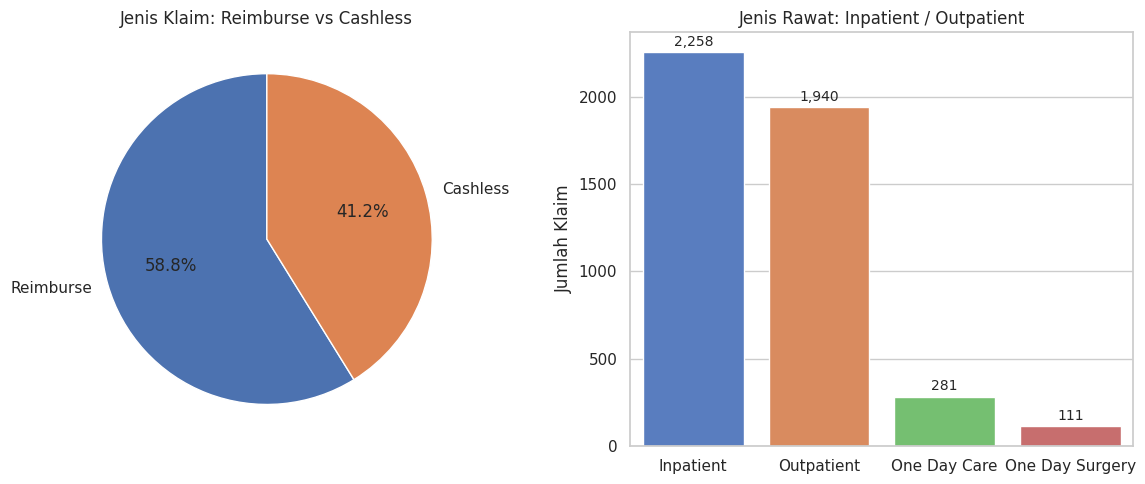

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Reimburse vs Cashless
rc_counts = data_klaim['Reimburse/Cashless'].map({'R': 'Reimburse', 'C': 'Cashless'}).value_counts()
axes[0].pie(rc_counts, labels=rc_counts.index, autopct='%1.1f%%', startangle=90,
            colors=['#4C72B0', '#DD8452'])
axes[0].set_title('Jenis Klaim: Reimburse vs Cashless')

# Inpatient/Outpatient
ip_order = data_klaim['Inpatient/Outpatient'].value_counts()
ip_label = {'IP': 'Inpatient', 'OP': 'Outpatient', 'ODC': 'One Day Care', 'ODS': 'One Day Surgery'}
ip_counts = ip_order.rename(index=ip_label)
sns.barplot(x=ip_counts.index, y=ip_counts.values, ax=axes[1], palette='muted')
axes[1].set_title('Jenis Rawat: Inpatient / Outpatient')
axes[1].set_xlabel('')
axes[1].set_ylabel('Jumlah Klaim')
for bar, val in zip(axes[1].patches, ip_counts.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20, f'{val:,}',
                 ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

## 3. Distribusi Lokasi RS

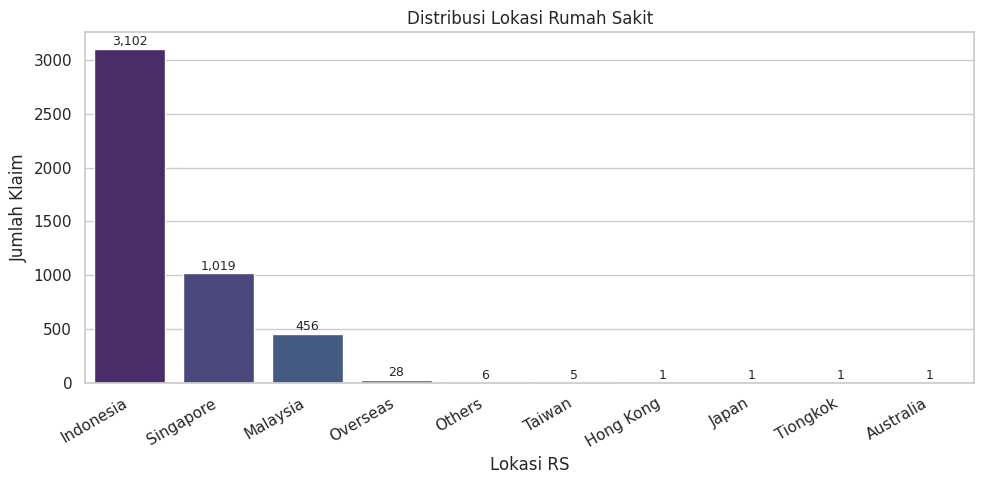

In [37]:
lokasi_counts = data_klaim['Lokasi RS'].value_counts()

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(x=lokasi_counts.index, y=lokasi_counts.values, ax=ax, palette='viridis')
ax.set_title('Distribusi Lokasi Rumah Sakit')
ax.set_xlabel('Lokasi RS')
ax.set_ylabel('Jumlah Klaim')
for bar, val in zip(ax.patches, lokasi_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5, f'{val:,}',
            ha='center', va='bottom', fontsize=9)
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

## 4. Distribusi Nominal Klaim

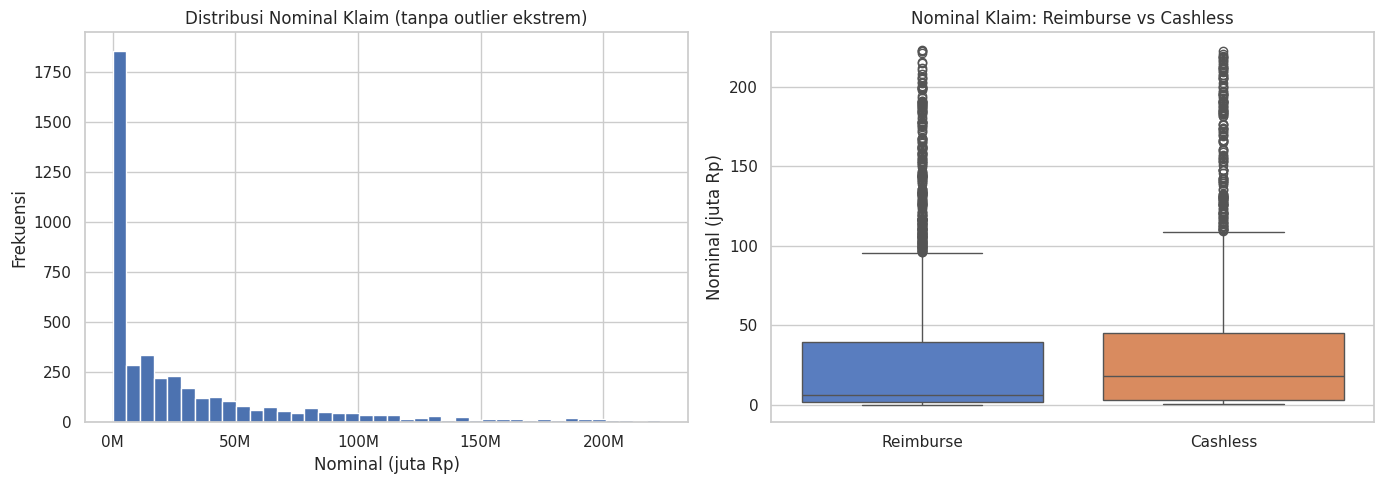

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram nominal klaim
klaim_val = data_klaim['Nominal Klaim Yang Disetujui'] / 1e6  # dalam jutaan
axes[0].hist(klaim_val[klaim_val <= klaim_val.quantile(0.95)], bins=40, color='#4C72B0', edgecolor='white')
axes[0].set_title('Distribusi Nominal Klaim (tanpa outlier ekstrem)')
axes[0].set_xlabel('Nominal (juta Rp)')
axes[0].set_ylabel('Frekuensi')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}M'))

# Boxplot per jenis klaim
data_box = data_klaim.copy()
data_box['Jenis'] = data_box['Reimburse/Cashless'].map({'R': 'Reimburse', 'C': 'Cashless'})
data_box['Nominal (juta)'] = data_box['Nominal Klaim Yang Disetujui'] / 1e6
q95 = data_box['Nominal (juta)'].quantile(0.95)
sns.boxplot(data=data_box[data_box['Nominal (juta)'] <= q95],
            x='Jenis', y='Nominal (juta)', ax=axes[1], palette='muted')
axes[1].set_title('Nominal Klaim: Reimburse vs Cashless')
axes[1].set_xlabel('')
axes[1].set_ylabel('Nominal (juta Rp)')

plt.tight_layout()
plt.show()

## 5. Top 10 Diagnosis (ICD)

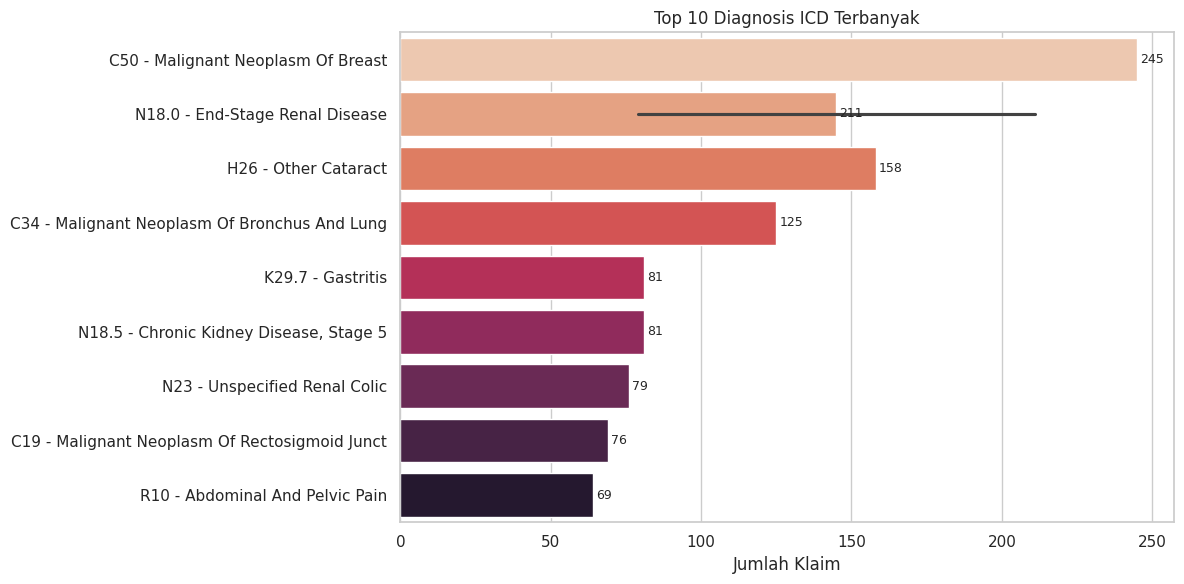

In [39]:
top_icd = data_klaim.groupby(['ICD Diagnosis', 'ICD Description'])['Claim ID'].count() \
                    .reset_index().rename(columns={'Claim ID': 'Jumlah'}) \
                    .sort_values('Jumlah', ascending=False).head(10)
top_icd['Label'] = top_icd['ICD Diagnosis'] + ' - ' + top_icd['ICD Description'].str.title().str[:40]

fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(data=top_icd, y='Label', x='Jumlah', ax=ax, palette='rocket_r')
ax.set_title('Top 10 Diagnosis ICD Terbanyak')
ax.set_xlabel('Jumlah Klaim')
ax.set_ylabel('')
for bar, val in zip(ax.patches, top_icd['Jumlah']):
    ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2, f'{val:,}',
            va='center', fontsize=9)
plt.tight_layout()
plt.show()

## 6. Tren Klaim per Bulan

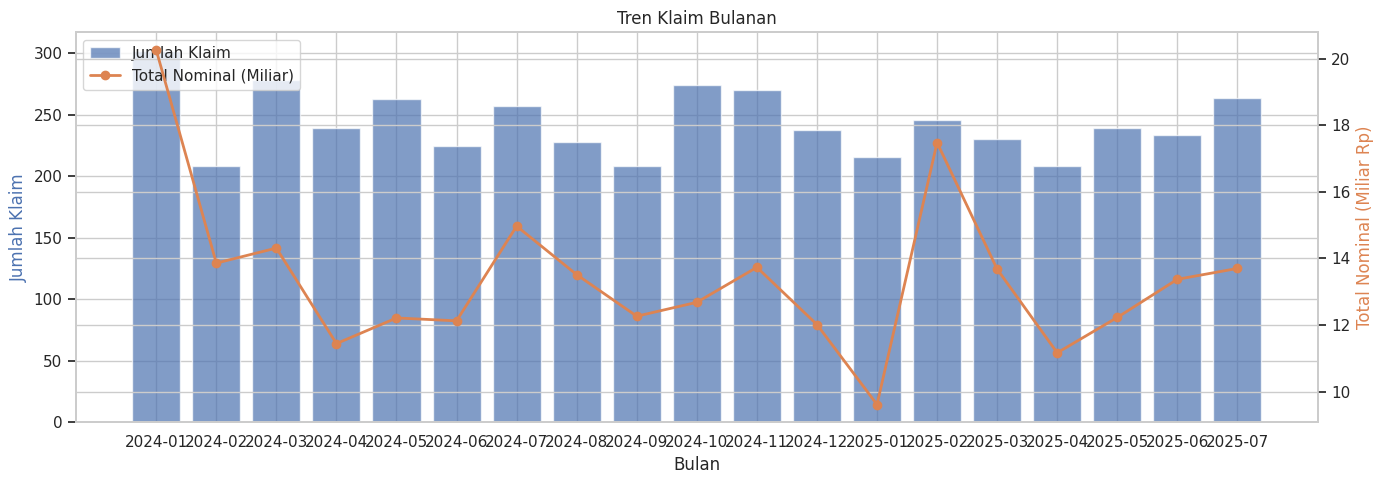

In [42]:
monthly = data_klaim.dropna(subset=['Tanggal Pasien Masuk RS']).copy()
monthly['YearMonth'] = monthly['Tanggal Pasien Masuk RS'].dt.to_period('M')
trend = monthly.groupby('YearMonth').agg(
    Jumlah_Klaim=('Claim ID', 'count'),
    Total_Nominal=('Nominal Klaim Yang Disetujui', 'sum')
).reset_index()
trend['YearMonth'] = trend['YearMonth'].astype(str)

fig, ax1 = plt.subplots(figsize=(14, 5))
ax2 = ax1.twinx()

ax1.bar(trend['YearMonth'], trend['Jumlah_Klaim'], color='#4C72B0', alpha=0.7, label='Jumlah Klaim')
ax2.plot(trend['YearMonth'], trend['Total_Nominal']/1e9, color='#DD8452', marker='o', linewidth=2, label='Total Nominal (Miliar)')

ax1.set_title('Tren Klaim Bulanan')
ax1.set_xlabel('Bulan')
ax1.set_ylabel('Jumlah Klaim', color='#4C72B0')
ax2.set_ylabel('Total Nominal (Miliar Rp)', color='#DD8452')
plt.xticks(rotation=45, ha='right')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.tight_layout()
plt.show()

## 7. Lama Rawat Inap (Length of Stay)

Rata-rata LOS Inpatient : 2.3 hari
Median LOS Inpatient    : 2 hari
Max LOS Inpatient       : 17 hari


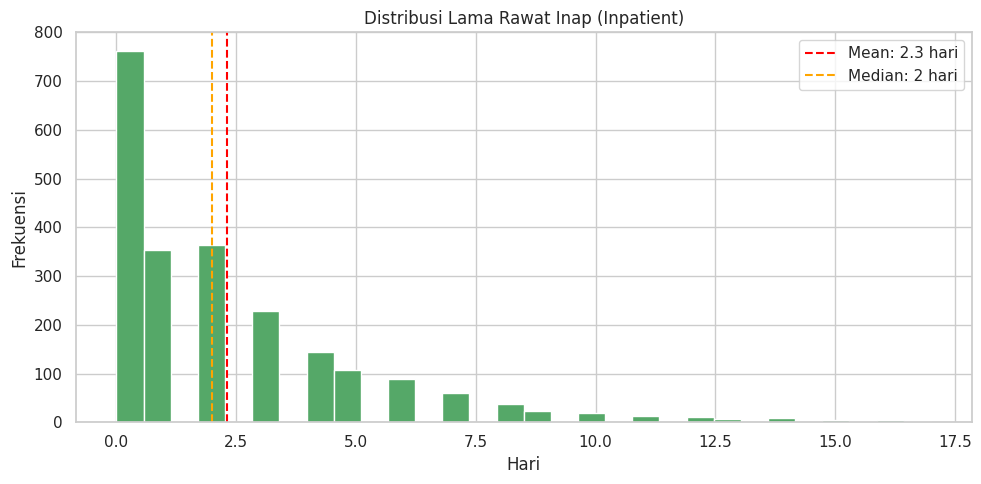

In [43]:
los = data_klaim.copy()
los['LOS'] = (los['Tanggal Pasien Keluar RS'] - los['Tanggal Pasien Masuk RS']).dt.days
los_ip = los[los['Inpatient/Outpatient'] == 'IP']['LOS'].dropna()
los_ip = los_ip[(los_ip >= 0) & (los_ip <= los_ip.quantile(0.99))]

print(f"Rata-rata LOS Inpatient : {los_ip.mean():.1f} hari")
print(f"Median LOS Inpatient    : {los_ip.median():.0f} hari")
print(f"Max LOS Inpatient       : {los_ip.max():.0f} hari")

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(los_ip, bins=30, color='#55A868', edgecolor='white')
ax.set_title('Distribusi Lama Rawat Inap (Inpatient)')
ax.set_xlabel('Hari')
ax.set_ylabel('Frekuensi')
ax.axvline(los_ip.mean(), color='red', linestyle='--', label=f'Mean: {los_ip.mean():.1f} hari')
ax.axvline(los_ip.median(), color='orange', linestyle='--', label=f'Median: {los_ip.median():.0f} hari')
ax.legend()
plt.tight_layout()
plt.show()

## 8. Korelasi Nominal Klaim vs Biaya RS

Korelasi Pearson: 0.9877


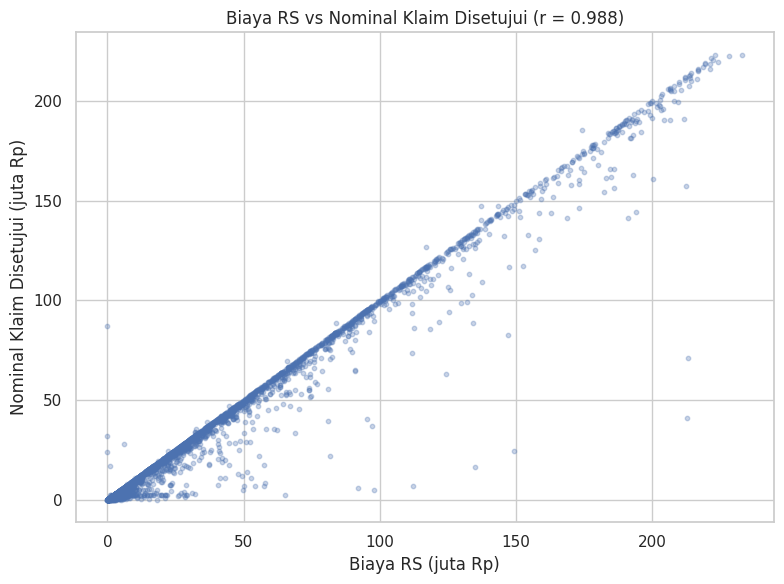

In [44]:
scatter_df = data_klaim[['Nominal Klaim Yang Disetujui', 'Nominal Biaya RS Yang Terjadi']].copy() / 1e6
q95 = scatter_df.quantile(0.95)
scatter_df = scatter_df[(scatter_df <= q95).all(axis=1)]

corr = scatter_df.corr().iloc[0, 1]
print(f"Korelasi Pearson: {corr:.4f}")

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(scatter_df['Nominal Biaya RS Yang Terjadi'],
           scatter_df['Nominal Klaim Yang Disetujui'],
           alpha=0.3, s=10, color='#4C72B0')
ax.set_xlabel('Biaya RS (juta Rp)')
ax.set_ylabel('Nominal Klaim Disetujui (juta Rp)')
ax.set_title(f'Biaya RS vs Nominal Klaim Disetujui (r = {corr:.3f})')
plt.tight_layout()
plt.show()

## 9. Rata-rata Nominal Klaim per Lokasi RS

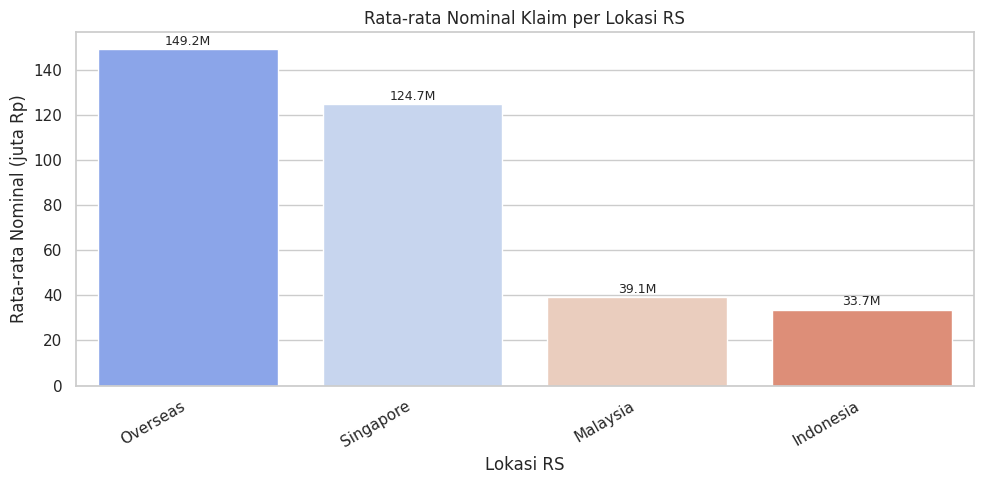

In [45]:
avg_per_lokasi = data_klaim.groupby('Lokasi RS')['Nominal Klaim Yang Disetujui'].mean().sort_values(ascending=False) / 1e6
avg_per_lokasi = avg_per_lokasi[avg_per_lokasi.index.isin(
    data_klaim['Lokasi RS'].value_counts()[data_klaim['Lokasi RS'].value_counts() >= 10].index
)]

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(x=avg_per_lokasi.index, y=avg_per_lokasi.values, ax=ax, palette='coolwarm')
ax.set_title('Rata-rata Nominal Klaim per Lokasi RS')
ax.set_xlabel('Lokasi RS')
ax.set_ylabel('Rata-rata Nominal (juta Rp)')
for bar, val in zip(ax.patches, avg_per_lokasi.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, f'{val:.1f}M',
            ha='center', va='bottom', fontsize=9)
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()